# **ARIMA**
D8 solutions

As a baseline, the current collision-parts forecast (using the generic model) has a WMAPE of around 70% using a 2-month lag and a 3-month rolling average.

Forecast requirements:

- Granularity: Provide monthly forecasts at the SKU level, for the defined collision parts scope.
- Horizon: Forecast 18 months ahead, updated monthly.
- Accuracy metric: Use WMAPE, assessed with:
  - 3-month forecast lag (forecasts are judged against actuals two months later)
  - 3-month rolling average of WMAPE (to smooth month-to-month noise)
- Benchmarking: Compare results against the current baseline model, with improvement reported in WMAPE points and %.
- Backtesting: Use a rolling-origin backtest that matches the real operating cadence (train on history, predict forward with the 3-month lag).
- Edge cases: Be explicit about how you handle:
  - Zero-demand months (common in collision parts)
  - New / discontinued / superseded SKUs
- Outputs: Provide forecasts plus a short explanation of what drives performance (where it works well, where it struggles, and why) and provide the meaning of the features used.

Although Auto ARIMA was initially considered, it proved computationally impractical for this study. The rolling-origin backtest required refitting a model for every SKU at every forecast origin. Since Auto ARIMA performs an exhaustive search over multiple ARIMA orders for each fit, the computational cost increased substantially across thousands of SKU-level models.

To ensure a fair and computationally feasible comparison, a fixed ARIMA(1,1,1) specification was adopted. This removes the repeated model-order search while retaining the core autoregressive, differencing, and moving-average components of the ARIMA framework. The chosen specification is widely used as a general-purpose benchmark in time-series forecasting and provides a consistent basis for comparison across all demand types.

In [124]:
# Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown
import os
import warnings

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [125]:
# Load data

spreadsheet_id = "1QX9PieVqefPa7A9R99q7BSSUl36Dqm66nn9oEb8iMZY"
gid = "1717943535"

url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={gid}"

sales_collision = pd.read_csv(url)

sales_collision.head()

,ts_id,Date,REVENUE,COST,UNIT_PRICE,TOTAL_PROFIT,UNIT_COST,STOCK_END_MONTH,STOCK_START_MONTH,NEW_ENTRY_STOCK,...,CURRENCY,value,collision_flag,sku_id,date,demand,collision_flag_clean,is_collision,month,demand_type
0,083144012A000,2024-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,083144012A000,2024-08-01,0,COLLISION,True,2024-08-01,Intermittent
1,09148M06022000,2025-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USD,0,COLLISION,09148M06022000,2025-01-01,0,COLLISION,True,2025-01-01,Intermittent
2,926225187000,2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,926225187000,2025-10-01,0,COLLISION,True,2025-10-01,Intermittent
3,928044008000,2024-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,928044008000,2024-06-01,0,COLLISION,True,2024-06-01,Intermittent
4,928044008000,2024-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,928044008000,2024-12-01,0,COLLISION,True,2024-12-01,Intermittent


In [126]:
print(f"There are {sales_collision.shape[0]} rows")
print(f"There are {sales_collision.shape[1]} columns\n")

print(f"Unique SKUs : {sales_collision['sku_id'].nunique()}\n")

print(sales_collision['demand_type'].unique())

# unique sku by demand type
print("")
print(
    sales_collision
    .groupby("sku_id")["demand_type"]
    .first()
    .value_counts()
)

# total demand by demand type
print("")
print(
    sales_collision
    .groupby("demand_type")["demand"]
    .sum()
)

There are 180422 rows
There are 48 columns

Unique SKUs : 8097

['Intermittent' 'Lumpy' 'Smooth' 'Erratic' 'No demand observed']

demand_type
Intermittent          6593
Smooth                 972
Lumpy                  381
Erratic                124
No demand observed      27
Name: count, dtype: int64

demand_type
Erratic                16049
Intermittent           52809
Lumpy                  12349
No demand observed         0
Smooth                156317
Name: demand, dtype: int64


In [127]:
total_demand_by_sku = (
    sales_collision
    .groupby("sku_id")["demand"]
    .sum()
    .rename("total_demand_sku")
)

sales_collision = sales_collision.merge(
    total_demand_by_sku,
    on="sku_id",
    how="left"
)

threshold = sales_collision["total_demand_sku"].quantile(0.80)

sales_collision["is_top20pct"] = (
    sales_collision["total_demand_sku"] >= threshold
).astype(int)

threshold = sales_collision["total_demand_sku"].quantile(0.95)

sales_collision["is_top5pct"] = (
    sales_collision["total_demand_sku"] >= threshold
).astype(int)

In [128]:
# Settings

FORECAST_LAG = 3
N_FORECAST = 18
MIN_TRAIN = 24

In [129]:
df = sales_collision[
    [
        "sku_id",
        "month",
        "demand",
        "demand_type"
    ]
].copy()

df["month"] = pd.to_datetime(df["month"])

df = (df.sort_values(["sku_id", "month"]).reset_index(drop=True))

print(df.head())

          sku_id      month  demand demand_type
0  015500612A000 2024-05-01       6       Lumpy
1  015500612A000 2024-06-01       0       Lumpy
2  015500612A000 2024-07-01       0       Lumpy
3  015500612A000 2024-08-01       0       Lumpy
4  015500612A000 2024-09-01       0       Lumpy


In [130]:
# WMAPE

def wmape(actual, forecast):

    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    if actual.sum() == 0:
        return np.nan

    return np.abs(actual - forecast).sum() / actual.sum()

In [131]:
# Baseline

def baseline_wmape(data):

    d = data.sort_values(
        ["sku_id", "month"]
    ).copy()

    d["baseline"] = (
        d.groupby("sku_id")["demand"]
        .transform(
            lambda x:
            x.shift(FORECAST_LAG)
            .rolling(3, min_periods=1)
            .mean()
        )
    )

    valid = d.dropna(subset=["baseline"])

    return wmape(
        valid["demand"],
        valid["baseline"]
    )

In [132]:
# Fixed ARIMA function

def fit_arima(train_series):

    model = ARIMA(
        train_series,
        order=(1,1,1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit()

    return fitted

In [133]:
def rolling_backtest(data):

    results = []

    # Process one SKU at a time
    for sku in data["sku_id"].unique():
        sku_df = (
            data[data["sku_id"] == sku]
            .sort_values("month")
            .reset_index(drop=True)
        )
        # Skip short series
        if len(sku_df) < (MIN_TRAIN + FORECAST_LAG):
            continue

        # Rolling-origin evaluation
        for origin in range(MIN_TRAIN, len(sku_df) - FORECAST_LAG + 1):
            train = sku_df.iloc[:origin]
            test = sku_df.iloc[origin + FORECAST_LAG - 1]
            train_series = train["demand"]
            try:
                model = fit_arima(train_series)
                forecast = model.forecast(
                    steps=FORECAST_LAG
                    )
                pred = max(0, forecast.iloc[-1])

            except Exception:
              continue

            results.append({
                "sku_id": sku,
                "cutoff": train["month"].iloc[-1],
                "pred_month": test["month"],
                "actual": test["demand"],
                "forecast": pred,
                "model": model

            })

    print(f"Generated {len(results):,} forecasts")
    return pd.DataFrame(results)

In [134]:
DEMAND_TYPES = [
    dt
    for dt in df["demand_type"].dropna().unique()
    if dt != "No demand observed"
]

In [135]:
# Train Models Per Demand Type

models = {}
summary_rows = []

for dt in DEMAND_TYPES:

    subset = (
        df[df["demand_type"] == dt]
        .copy()
    )

    print()
    print("=" * 60)
    print(dt)
    print("=" * 60)

    # Baseline
    baseline = baseline_wmape(subset)

    # Rolling-origin backtest
    bt = rolling_backtest(subset)

    if len(bt) == 0:
        print("No valid forecasts.")
        continue

    monthly = (
        bt
        .groupby("pred_month")
        .apply(
            lambda g: wmape(
                g["actual"],
                g["forecast"]
            )
        )
        .rename("wmape")
        .reset_index()
    )

    monthly["rolling_wmape"] = (
        monthly["wmape"]
        .rolling(3, min_periods=1)
        .mean()
    )

    arima_wmape = monthly["rolling_wmape"].mean()

    improvement = baseline - arima_wmape

    print(f"Baseline    : {baseline:.4f}")
    print(f"ARIMA       : {arima_wmape:.4f}")
    print(f"Improvement : {improvement:+.4f}")

    models[dt] = bt

    summary_rows.append({
        "demand_type": dt,
        "baseline_wmape": round(baseline, 4),
        "arima_wmape": round(arima_wmape, 4),
        "improvement_pts": round(improvement, 4),
        "improvement_pct": round(improvement / baseline * 100, 2)
    })


Lumpy
Generated 322 forecasts
Baseline    : 1.3597
ARIMA       : 1.2111
Improvement : +0.1486

Intermittent
Generated 3,591 forecasts
Baseline    : 1.4436
ARIMA       : 1.1721
Improvement : +0.2715

Erratic
Generated 180 forecasts
Baseline    : 0.7635
ARIMA       : 0.7301
Improvement : +0.0335

Smooth
Generated 1,712 forecasts
Baseline    : 0.4663
ARIMA       : 0.5514
Improvement : -0.0851


In [136]:
summary_df = pd.DataFrame(summary_rows)

print("=" * 60)
print("SUMMARY")
print("=" * 60)

display(summary_df)

SUMMARY


,demand_type,baseline_wmape,arima_wmape,improvement_pts,improvement_pct
0,Lumpy,1.3597,1.2111,0.1486,10.93
1,Intermittent,1.4436,1.1721,0.2715,18.81
2,Erratic,0.7635,0.7301,0.0335,4.38
3,Smooth,0.4663,0.5514,-0.0851,-18.26


**Interpretation**

- Intermittent demand
  - This is the strongest result. ARIMA reduced WMAPE from 1.44 to 1.17, an improvement of almost 19%.
  - A likely explanation is that intermittent demand still contains some temporal dependence. ARIMA can learn from previous non-zero observations and short-term autocorrelation, whereas the simple rolling-average baseline cannot adapt as effectively.

- Lumpy demand
  - ARIMA also improved performance on lumpy demand by around 11%.
  - Although lumpy demand is highly irregular, some SKUs still exhibit enough structure for ARIMA to outperform the simple moving-average baseline. However, the absolute WMAPE remains high (>1.2), indicating that both approaches struggle to forecast highly sporadic demand accurately.

- Erratic demand
  - The improvement is modest (about 4%).
  - Erratic demand is characterised by frequent but highly variable sales. While ARIMA captures some temporal relationships, sudden demand spikes remain difficult to predict, limiting the overall improvement over the baseline.

- Smooth demand
  - This is the only category where ARIMA performed worse.
  - The baseline already achieves a WMAPE of 0.466, which is relatively low. For smooth demand, the recent 3-month moving average is already an effective predictor. Introducing ARIMA adds unnecessary model complexity and can lead to overfitting or estimation noise, resulting in slightly poorer forecast accuracy.

**Overall conclusion**

The fixed ARIMA model demonstrates clear benefits for Intermittent and Lumpy demand, modest gains for Erratic demand, but offers no advantage for Smooth demand. This suggests that ARIMA is most useful where historical demand exhibits some temporal structure that is not fully captured by the baseline, while a simple moving-average forecast remains sufficient for stable demand patterns.

In [137]:
forecast_parts = []

for dt in DEMAND_TYPES:

    subset = df[df["demand_type"] == dt]
    print(f"\nForecasting {dt}...")
    for sku in subset["sku_id"].unique():
        sku_df = (
            subset[subset["sku_id"] == sku]
            .sort_values("month")
            .reset_index(drop=True)
        )

        # Skip short series
        if len(sku_df) < MIN_TRAIN:
            continue
        train_series = sku_df["demand"].astype(float)

        # Skip constant series
        if train_series.nunique() <= 1:
            continue

        # Skip extremely sparse series
        if (train_series > 0).sum() < 3:
            continue

        try:
            model = fit_arima(train_series)
            fc = model.forecast(steps=N_FORECAST)

        except Exception:
            continue

        future_months = pd.date_range(
            start=sku_df["month"].max() + pd.DateOffset(months=1),
            periods=N_FORECAST,
            freq="MS"
        )

        temp = pd.DataFrame({
            "sku_id": sku,
            "month": future_months,
            "forecast": np.maximum(fc.values, 0),
            "demand_type": dt
        })

        forecast_parts.append(temp)

forecasts_18m = pd.concat(
    forecast_parts,
    ignore_index=True
)

forecasts_18m["horizon"] = (
    forecasts_18m
    .groupby("sku_id")
    .cumcount()
    + 1
)

print(f"\nForecast complete.")
print(f"{forecasts_18m['sku_id'].nunique():,} SKUs")
print(f"{len(forecasts_18m):,} forecast rows")

display(forecasts_18m.head())


Forecasting Lumpy...

Forecasting Intermittent...

Forecasting Erratic...

Forecasting Smooth...

Forecast complete.
4,059 SKUs
73,062 forecast rows


,sku_id,month,forecast,demand_type,horizon
0,0915912L02000,2026-05-01,0.000005,Lumpy,1
1,0915912L02000,2026-06-01,0.000005,Lumpy,2
2,0915912L02000,2026-07-01,0.000005,Lumpy,3
3,0915912L02000,2026-08-01,0.000005,Lumpy,4
4,0915912L02000,2026-09-01,0.000005,Lumpy,5


Prior to model fitting, three types of series were excluded from ARIMA forecasting. Short series (fewer than MIN_TRAIN observations) were omitted because they do not provide sufficient historical data to estimate ARIMA parameters reliably. Constant series were excluded because they contain no temporal variation, preventing the model from learning autoregressive or moving average relationships and often leading to convergence issues. Extremely sparse series (fewer than three non-zero demand observations) were also removed, as they contain insufficient demand events for ARIMA to identify meaningful patterns, resulting in unstable and unreliable forecasts. These filtering rules improve model robustness while ensuring forecasts are generated only for SKUs with adequate historical information.

In [138]:
insample_parts = []

for dt in DEMAND_TYPES:
    subset = df[df["demand_type"] == dt]

    for sku in subset["sku_id"].unique():
        sku_df = (
            subset[subset["sku_id"] == sku]
            .sort_values("month")
            .reset_index(drop=True)
        )

        if len(sku_df) < MIN_TRAIN:
            continue
        train_series = sku_df["demand"].astype(float)

        if train_series.nunique() <= 1:
            continue

        if (train_series > 0).sum() < 3:
            continue

        try:
            model = fit_arima(train_series)
            fitted = model.fittedvalues

        except Exception:
            continue

        temp = sku_df.copy()
        temp["arima_insample"] = np.maximum(fitted.values, 0)

        insample_parts.append(

            temp[
                [
                    "sku_id",
                    "month",
                    "arima_insample"
                ]
            ]
        )

insample_df = pd.concat(
    insample_parts,
    ignore_index=True
)

print(insample_df.shape)

display(insample_df.head())

(110074, 3)


,sku_id,month,arima_insample
0,0915912L02000,2024-05-01,0.000000
1,0915912L02000,2024-06-01,1.987358
2,0915912L02000,2024-07-01,5.949433
3,0915912L02000,2024-08-01,0.159402
4,0915912L02000,2024-09-01,0.002239


In [139]:
# Merge actual demand with ARIMA predictions

sku_eval = (
    df[
        [
            "sku_id",
            "month",
            "demand",
            "demand_type"
        ]
    ]
    .merge(
        insample_df,
        on=[
            "sku_id",
            "month"
        ],
        how="inner"
    )
)

print(sku_eval.shape)

(110074, 5)


In [140]:
# Calculate the baseline prediction

sku_eval = sku_eval.sort_values(
    [
        "sku_id",
        "month"
    ]
)

sku_eval["baseline"] = (
    sku_eval
    .groupby("sku_id")["demand"]
    .transform(
        lambda x:
        x.shift(FORECAST_LAG)
        .rolling(
            3,
            min_periods=1
        )
        .mean()
    )
)

sku_eval = sku_eval.dropna(
    subset=[
        "baseline",
        "arima_insample"
    ]
)

In [141]:
# Calculate WMAPE for every SKU

sku_wmape = (
    sku_eval
    .groupby(
        [
            "sku_id",
            "demand_type"
        ]
    )
    .apply(
        lambda g:
        pd.Series({
            "baseline_wmape":
                wmape(
                    g["demand"],
                    g["baseline"]
                ),
            "arima_wmape":
                wmape(
                    g["demand"],
                    g["arima_insample"]
                ),
            "total_demand":
                g["demand"].sum()
        })
    )
    .reset_index()
)

In [142]:
# Calculate improvement

sku_wmape["improvement_pct"] = (
    (sku_wmape["baseline_wmape"] - sku_wmape["arima_wmape"])
    /
    sku_wmape["baseline_wmape"] * 100
)

In [143]:
# Add Metadata

sku_meta = (
    sales_collision[
        [
            "sku_id",
            "total_demand_sku",
            "is_top20pct",
            "is_top5pct"
        ]
    ]
    .drop_duplicates()
)

sku_wmape = sku_wmape.merge(
    sku_meta,
    on="sku_id",
    how="left"
)

In [144]:
# Find improved SKUs

improved = (
    sku_wmape
    [
        sku_wmape["improvement_pct"] > 10
    ]
    .sort_values(
        "total_demand",
        ascending=False
    )
    .reset_index(drop=True)
)

print(f"{len(improved):,} SKUs improved by >10%")

display(improved.head(20))

2,245 SKUs improved by >10%


,sku_id,demand_type,baseline_wmape,arima_wmape,total_demand,improvement_pct,total_demand_sku,is_top20pct,is_top5pct
0,09409M07346000,Smooth,0.363376,0.242846,8965.0,33.169642,10211,1,1
1,09409M08006000,Erratic,0.790963,0.696970,2844.0,11.883387,3193,1,1
2,940907340000,Smooth,0.541234,0.414553,1253.0,23.405930,1537,1,1
3,911912012000,Smooth,0.489763,0.426156,1042.0,12.987420,1105,1,1
4,7173165J00000,Smooth,0.428989,0.360796,798.0,15.896228,906,1,1
5,71711M55T00799,Smooth,0.449030,0.357176,739.0,20.456164,782,1,1
6,928906003000,Lumpy,1.064033,0.809052,734.0,23.963600,766,1,1
7,71711M50S00799,Smooth,0.331325,0.288201,581.0,13.015844,683,1,1
8,71811M68P10799,Smooth,0.299226,0.242369,474.0,19.001532,560,1,1
9,71822M68P00000,Smooth,0.270521,0.235871,467.0,12.808762,537,1,1


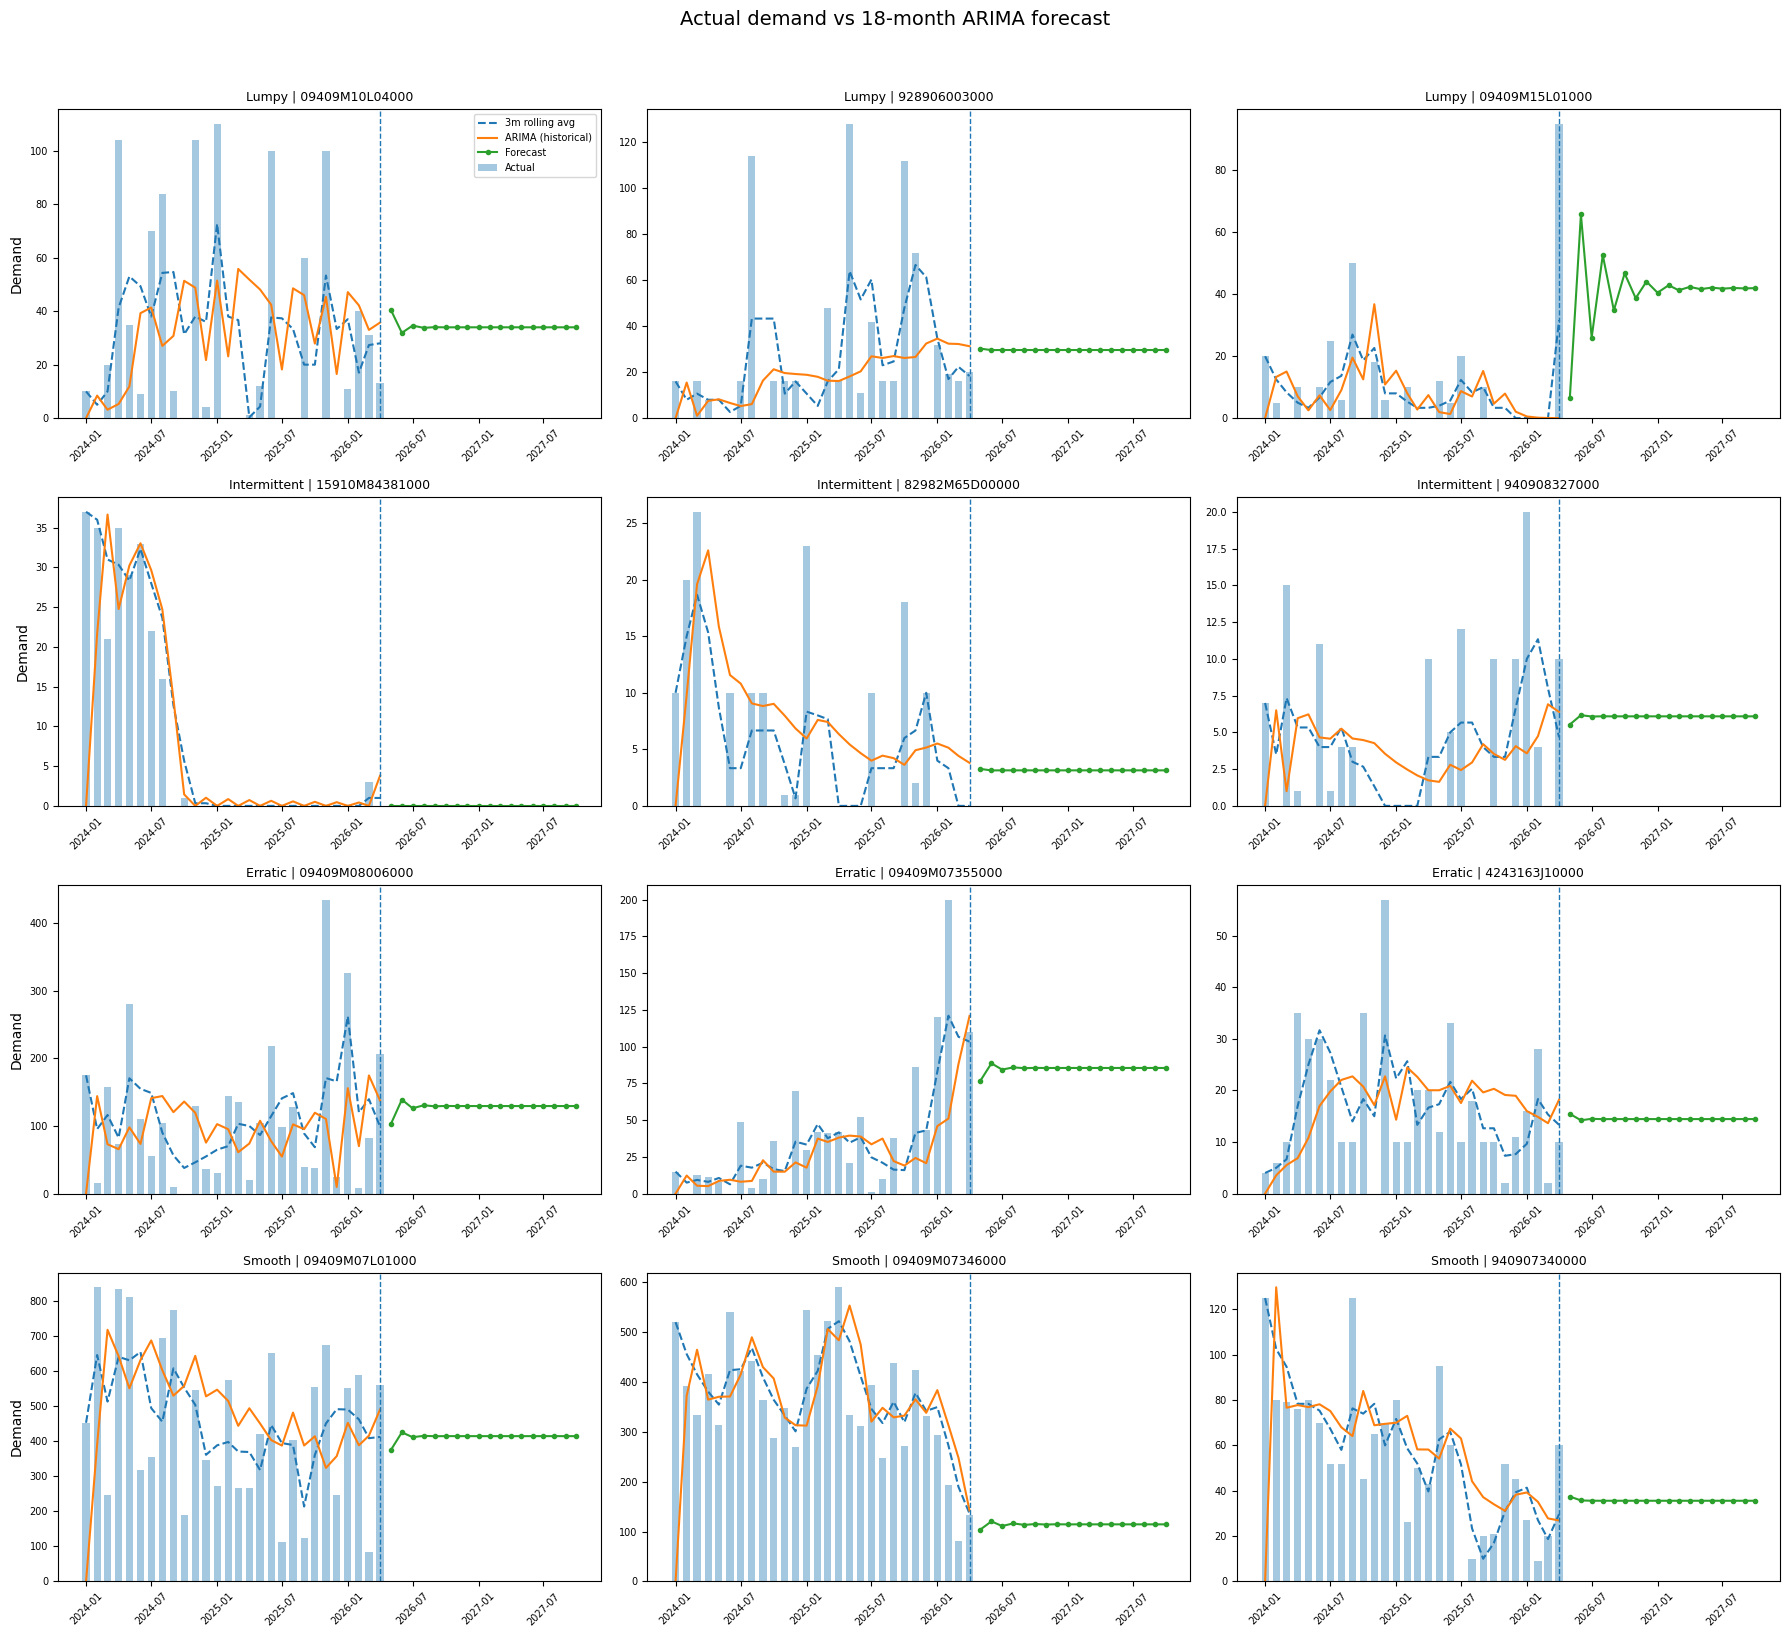

In [145]:
N_SKUS_PER_TYPE = 3

fig_rows = len(DEMAND_TYPES)

fig, axes = plt.subplots(
    fig_rows,
    N_SKUS_PER_TYPE,
    figsize=(18, fig_rows * 4)
)

fig.suptitle(
    "Actual demand vs 18-month ARIMA forecast",
    fontsize=14,
    y=1.02
)

for row_idx, dt in enumerate(DEMAND_TYPES):
    top_skus = (
        df[df["demand_type"] == dt]
        .groupby("sku_id")["demand"]
        .sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]
        actual = (
            df[df["sku_id"] == sku]
            [["month", "demand"]]
            .sort_values("month")
        )

        actual["rolling_avg"] = (
            actual["demand"]
            .rolling(3, min_periods=1)
            .mean()
        )

        arima_hist = (
            insample_df
            [insample_df["sku_id"] == sku]
            .sort_values("month")
        )

        future = (
            forecasts_18m
            [forecasts_18m["sku_id"] == sku]
            .sort_values("month")
        )

        ax.bar(
            actual["month"],
            actual["demand"],
            alpha=0.4,
            width=20,
            label="Actual"
        )

        ax.plot(
            actual["month"],
            actual["rolling_avg"],
            linestyle="--",
            linewidth=1.5,
            label="3m rolling avg"

        )

        ax.plot(
            arima_hist["month"],
            arima_hist["arima_insample"],
            linewidth=1.5,
            label="ARIMA (historical)"
        )

        ax.plot(
            future["month"],
            future["forecast"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label="Forecast"
        )

        ax.axvline(
            df["month"].max(),
            linestyle="--",
            linewidth=1
        )

        ax.set_title(
            f"{dt} | {sku}",
            fontsize=9
        )

        ax.tick_params(
            axis="x",
            rotation=45,
            labelsize=7
        )

        ax.tick_params(
            axis="y",
            labelsize=7
        )

        if col_idx == 0:
            ax.set_ylabel("Demand")

        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [146]:
# Save the 18-month Forecasts

improved_skus = set(improved["sku_id"])

forecasts_18m["is_improved"] = (
    forecasts_18m["sku_id"]
    .isin(improved_skus)
    .astype(int)
)

# Add SKU metadata
sku_meta = sales_collision[
    [
        "sku_id",
        "is_top20pct",
        "is_top5pct"
    ]
].drop_duplicates()

forecasts_18m = forecasts_18m.merge(
    sku_meta,
    on="sku_id",
    how="left"
)

# Optional: clean tiny values
forecasts_18m["forecast"] = (
    forecasts_18m["forecast"]
    .clip(lower=0)
    .round(2)
)

# Save
forecasts_18m.to_csv(
    "arima_forecasts_18m.csv",
    index=False
)

print("Saved - arima_forecasts_18m.csv")

Saved - arima_forecasts_18m.csv


In [147]:
# WMAPE Distribution by Demand Type

bins = [0,0.3,0.5,0.7,1.0,1.5,2.0,float("inf")]

labels = [
    "<30%",
    "30-50%",
    "50-70%",
    "70-100%",
    "100-150%",
    "150-200%",
    ">200%"
]

sku_wmape["wmape_band"] = pd.cut(
    sku_wmape["arima_wmape"],
    bins=bins,
    labels=labels
)

band_counts = (
    sku_wmape["wmape_band"]
    .value_counts()
    .sort_index()
)

band_pct = (
    band_counts
    / len(sku_wmape)
    * 100
).round(1)

print(
    pd.DataFrame({
        "n_skus": band_counts,
        "pct_of_skus": band_pct
    })
)

            n_skus  pct_of_skus
wmape_band                     
<30%            69          1.7
30-50%         374          9.2
50-70%         565         13.9
70-100%        715         17.6
100-150%      1276         31.4
150-200%       696         17.1
>200%          364          9.0


In [148]:
mask = sku_wmape["arima_wmape"] < 0.70

result = (
    sku_wmape[mask]
    .groupby(["demand_type", "is_top20pct"])
    .size()
    .reset_index(name="n_skus_wmape_lt70")
)

# Total SKUs in each group
totals = (
    sku_wmape
    .groupby(["demand_type", "is_top20pct"])
    .size()
    .reset_index(name="total_skus")
)

result = result.merge(
    totals,
    on=["demand_type", "is_top20pct"]
)

result["pct_of_group"] = (
    result["n_skus_wmape_lt70"]
    / result["total_skus"]
    * 100
).round(1)

result["is_top20pct"] = result["is_top20pct"].map({
    1: "Top 20%",
    0: "Non top 20%"
})

print("SKUs with WMAPE < 70% by demand type and tier:")

display(
    result.sort_values(
        ["demand_type", "is_top20pct"]
    )
)

SKUs with WMAPE < 70% by demand type and tier:


,demand_type,is_top20pct,n_skus_wmape_lt70,total_skus,pct_of_group
0,Erratic,Top 20%,59,100,59.0
1,Intermittent,Non top 20%,60,2623,2.3
2,Intermittent,Top 20%,42,202,20.8
3,Lumpy,Non top 20%,1,145,0.7
4,Lumpy,Top 20%,7,87,8.0
5,Smooth,Non top 20%,10,11,90.9
6,Smooth,Top 20%,829,891,93.0


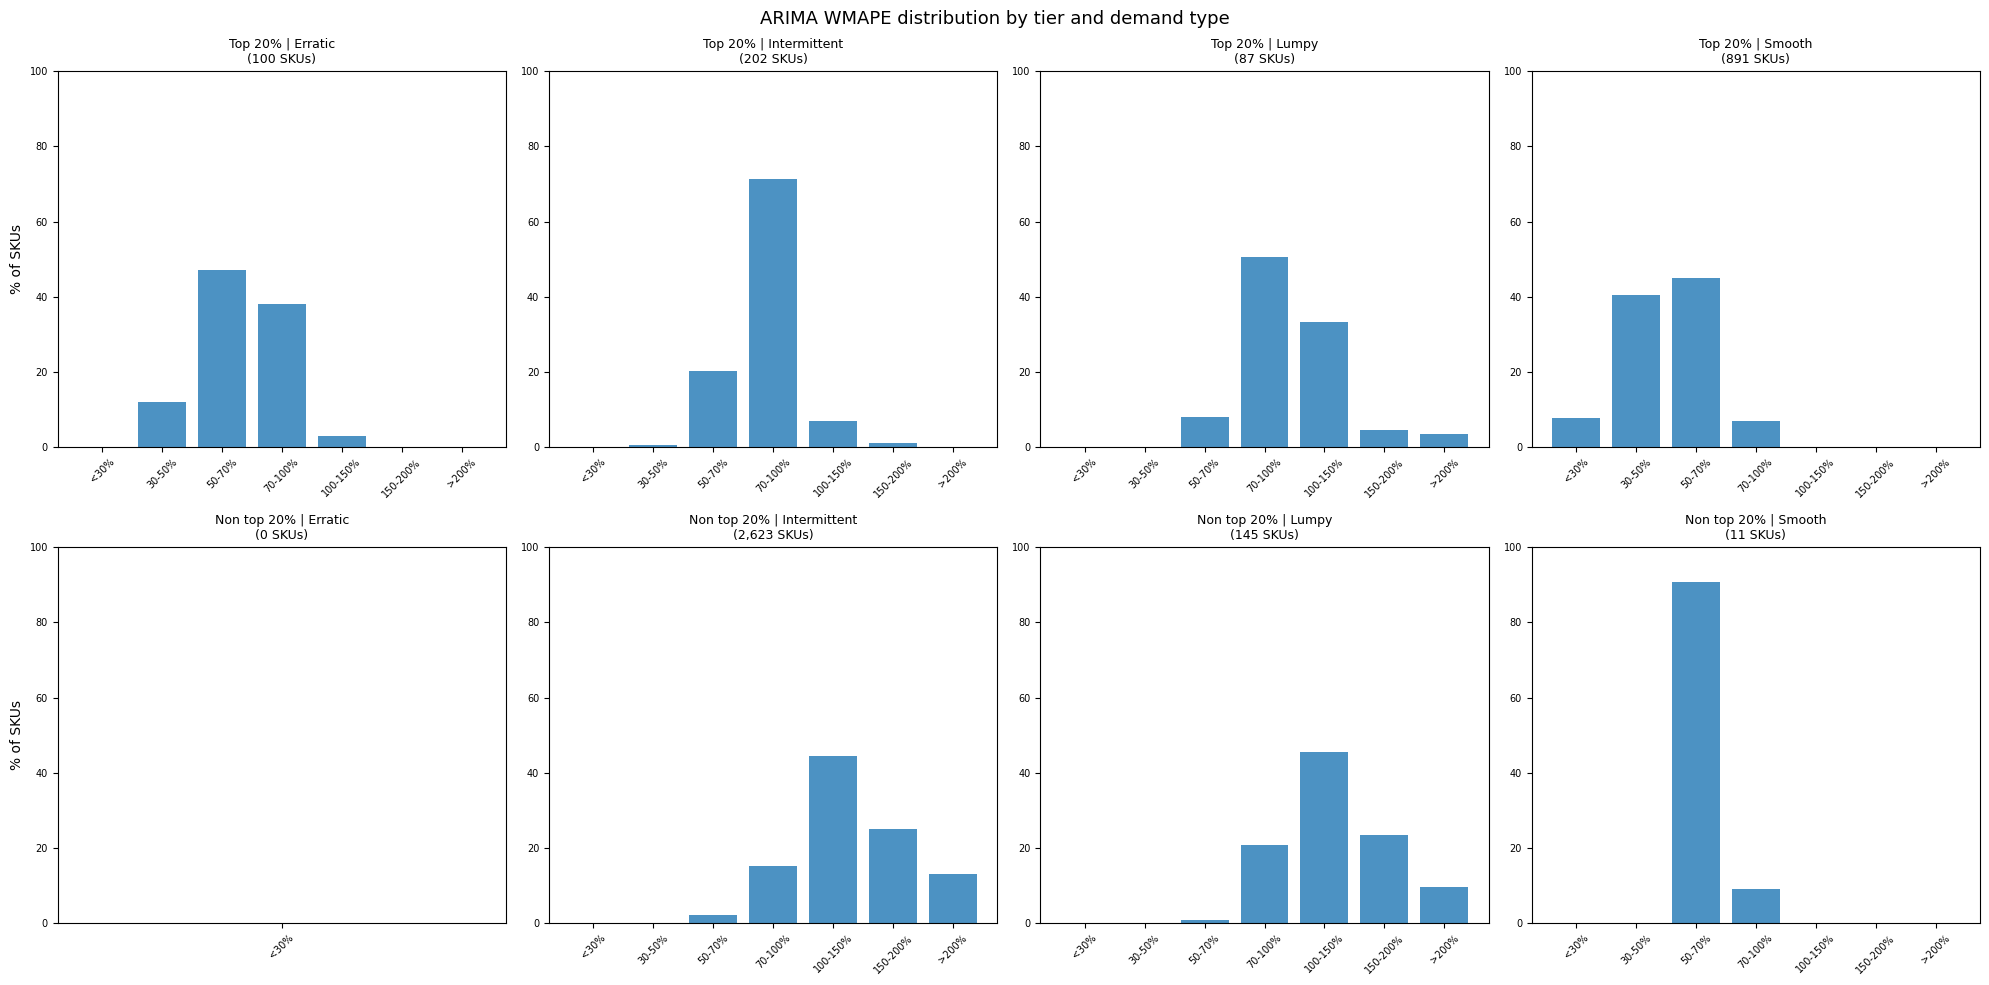

In [149]:
bins = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, float("inf")]

labels = [
    "<30%",
    "30-50%",
    "50-70%",
    "70-100%",
    "100-150%",
    "150-200%",
    ">200%"
]

sku_wmape["wmape_band"] = pd.cut(
    sku_wmape["arima_wmape"],
    bins=bins,
    labels=labels
)

demand_types = sorted(
    sku_wmape["demand_type"].dropna().unique()
)

tiers = [
    (1, "Top 20%"),
    (0, "Non top 20%")
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20,10)
)

fig.suptitle(
    "ARIMA WMAPE distribution by tier and demand type",
    fontsize=13
)

for row_idx, (tier, tier_label) in enumerate(tiers):

    tier_subset = sku_wmape[
        sku_wmape["is_top20pct"] == tier
    ]

    for col_idx, dt in enumerate(demand_types):
        ax = axes[row_idx][col_idx]
        subset = tier_subset[
            tier_subset["demand_type"] == dt
        ]

        band_counts = (
            subset["wmape_band"]
            .value_counts()
            .sort_index()
        )

        band_pct = (
            band_counts
            / len(subset)
            * 100
        ).round(1)

        ax.bar(
            band_counts.index,
            band_pct,
            alpha=0.8
        )

        ax.set_title(
            f"{tier_label} | {dt}\n({len(subset):,} SKUs)",
            fontsize=9
        )

        ax.set_ylim(0,100)

        ax.tick_params(
            axis="x",
            rotation=45,
            labelsize=7
        )

        ax.tick_params(
            axis="y",
            labelsize=7
        )

        if col_idx == 0:
            ax.set_ylabel("% of SKUs")

    # Hide unused panels
    for col_idx in range(len(demand_types), 4):
        axes[row_idx][col_idx].set_visible(False)

plt.tight_layout()
plt.show()

In [153]:
print("=" * 60)
print("ARIMA Demand Forecasting — Results Summary")
print("=" * 60)

print("\nScope")
print(f"  Total collision SKUs          : {sales_collision['sku_id'].nunique():,}")
print(f"  Total rows                    : {sales_collision.shape[0]:,}")
print(f"  Forecast horizon              : {N_FORECAST} months")
print(f"  Forecast lag                  : {FORECAST_LAG} months")

print("\nDemand type distribution")

dt_counts = (
    sales_collision
    .groupby("sku_id")["demand_type"]
    .first()
    .value_counts()
)

for dt, n in dt_counts.items():
    print(f"  {dt:<25}: {n:,} SKUs")

print("\nWMAPE comparison (Baseline vs ARIMA)")
print(f"{'Demand type':<15}{'Baseline':>12}{'ARIMA':>12}{'Improvement':>15}")
print("-" * 54)

for _, row in summary_df.iterrows():

    print(
        f"{row['demand_type']:<15}"
        f"{row['baseline_wmape']:>12.4f}"
        f"{row['arima_wmape']:>12.4f}"
        f"{row['improvement_pct']:>14.1f}%"
    )

print("\nSKU-level improvement (>10% WMAPE reduction)")

print(f"  Improved SKUs                 : {len(improved):,}")

total_in_top20 = sku_meta[sku_meta["is_top20pct"] == 1]["sku_id"].nunique()
total_in_top5  = sku_meta[sku_meta["is_top5pct"] == 1]["sku_id"].nunique()

imp_top20 = improved[
    improved["is_top20pct"] == 1
]["sku_id"].nunique()

imp_top5 = improved[
    improved["is_top5pct"] == 1
]["sku_id"].nunique()

print(
    f"  Improved in top 20% SKUs      : "
    f"{imp_top20:,} of {total_in_top20:,} "
    f"({imp_top20/total_in_top20*100:.1f}%)"
)

print(
    f"  Improved in top 5% SKUs       : "
    f"{imp_top5:,} of {total_in_top5:,} "
    f"({imp_top5/total_in_top5*100:.1f}%)"
)

print("\nKey findings")

best = summary_df.loc[
    summary_df["improvement_pct"].idxmax()
]

worst = summary_df.loc[
    summary_df["improvement_pct"].idxmin()
]

print(
    f"  • Strongest improvement: "
    f"{best['demand_type']} "
    f"({best['improvement_pct']:+.1f}%)"
)

print(
    f"  • Weakest performance: "
    f"{worst['demand_type']} "
    f"({worst['improvement_pct']:+.1f}%)"
)

print(
    "  • ARIMA performs particularly well for demand patterns "
    "with recurring temporal structure."
)

print(
    "  • Smooth demand is already well predicted by the simple "
    "rolling-average baseline, limiting further gains."
)

print(
    "  • Lumpy demand remains the most challenging despite "
    "improving over the baseline."
)

ARIMA Demand Forecasting — Results Summary

Scope
  Total collision SKUs          : 8,097
  Total rows                    : 180,422
  Forecast horizon              : 18 months
  Forecast lag                  : 3 months

Demand type distribution
  Intermittent             : 6,593 SKUs
  Smooth                   : 972 SKUs
  Lumpy                    : 381 SKUs
  Erratic                  : 124 SKUs
  No demand observed       : 27 SKUs

WMAPE comparison (Baseline vs ARIMA)
Demand type        Baseline       ARIMA    Improvement
------------------------------------------------------
Lumpy                1.3597      1.2111          10.9%
Intermittent         1.4436      1.1721          18.8%
Erratic              0.7635      0.7301           4.4%
Smooth               0.4663      0.5514         -18.3%

SKU-level improvement (>10% WMAPE reduction)
  Improved SKUs                 : 2,245
  Improved in top 20% SKUs      : 697 of 1,325 (52.6%)
  Improved in top 5% SKUs       : 176 of 325 (54.2%)

K

In [154]:
from google.colab import files

files.download("arima_forecasts_18m.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>